In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time

In [2]:
def func(x):
    F, FN, LN = 21, 22, 1
    return np.exp(-0.01 * F * x) + np.exp(0.01 * FN * x) + LN * x ** 2

def df(x):
    F, FN, LN = 21, 22, 1
    return (-0.01 * F * x) * np.exp(-0.01 * F) + (0.01 * FN) * np.exp(0.01 * FN * x) + 2 * LN * x

Посмотрим на функцию, убедимся, что она унимодальна

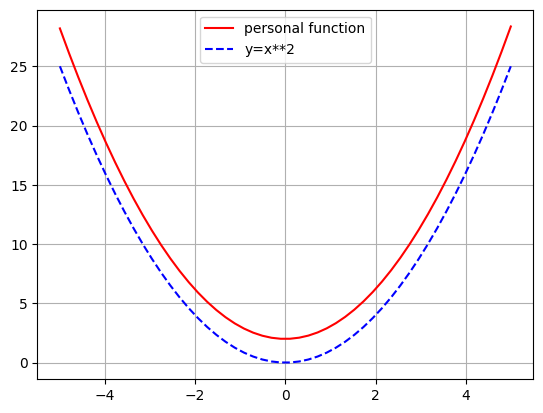

In [3]:
Ox = np.linspace(-5, 5, 50)
y = [func(x) for x in Ox]

plt.plot(Ox, y, 'r-', label = 'personal function')
plt.plot(Ox, [x ** 2 for x in Ox], 'b--', label = 'y=x**2')
plt.legend()
plt.grid()

In [4]:
# def dichotomy(a, b, eps, x: list, max_iter = 10 ** 3):
#     delta = eps / 2
#     result = 0
#     cur_iter = 0
#     # while b - a >= eps and cur_iter < max_iter:
#     while b - a >= eps:
#         cur_iter += 1
#         if x.size == 0:
#             print('x.size = 0')
#             break
            
#         result = (a+b) / 2
        
#         a1, b1 = (a + b)/2 - delta, (a + b)/2 + delta
#         left_value, right_value = func(a1), func(b1)
#         if left_value < right_value:
#             b = b1
#             x = x[x < b]
#         elif left_value > right_value:
#             a = a1
#             x = x[x > a]
#         else: 
#             a, b = a1, b1
#             x = x[(a <= x) & (x <= b)]
              
#     return result
# x = np.linspace(-5, 5, 10 ** 3)
# res = dichotomy(a=-5, b=5, eps=10 ** -8, x=x)
# # res_df = min([abs(df(x)) for x in x])
# res, res_df, func(res), func(res_df)

In [5]:
from IPython.display import display, clear_output


# декоратор для визуализации
def visualize_optimization(method):
    
    def wrapper(*args, **kwargs):
        
        def update_plot(a, b, eps, x_min, iteration):
            # добавил для того, чтобы юпитер обновлял график, а не добавлял новые
            clear_output(wait=True) 
            
            plt.clf()  # очищаем график
            
            # генерируем массив чисел для оси Ох и соответсвующие значения функции
            x = np.linspace(-1, 1, 1000)
            y = func(x)
            
            plt.plot(x, y, label="f(x)", color="blue")  # рисуем график
            
            # отображаем линии, соответствующие текущим a и b - границам дихотомии
            plt.axvline(a, color="red", linestyle="--", label=f"a = {a:.5f}")
            plt.axvline(b, color="green", linestyle="--", label=f"b = {b:.5f}")
            
            # отображаем значение функции от текущего минимайзера
            plt.scatter([x_min], [func(x_min)], color="black", zorder=3, label=f"x_min = {x_min:.5f}\nf(x_min) = {func(x_min):.5f}")
            
            plt.legend()
            plt.title(f"Итерация {iteration}")
            plt.xlabel("x")
            plt.ylabel("f(x)")

            # строчка для обновления графика, а не создания нового
            display(plt.gcf())
            # если нужно самостоятельно обновлять график, то раскомментируем инпут()
            # input()
            plt.pause(0.2)  # делаем паузы между каждым обновлением графика для того, чтобы успеть что-то рассмотреть
            # if b - a < eps:    break
        # запускаем метод оптимизации, передавая `update_plot` как callback
        return method(*args, update_plot=update_plot, **kwargs)
        
    return wrapper

# метод дихотомии с визуализацией
@visualize_optimization
def dichotomy(a, b, eps, update_plot=None):
    iteration = 0

    while b - a >= eps:
        iteration += 1
        delta = eps * 2 #(b - a) * 0.1  # можем использовать меняющуюся дельту

        a1, b1 = (a + b) / 2 - delta, (a + b) / 2 + delta
        left_value, right_value = func(a1), func(b1)

        if left_value < right_value:
            b = b1  # обновляем правую границу поиска
        elif left_value > right_value:
            a = a1  # обновляем левую границу поиска
        else:
            a, b = a1, b1  # обе границы, если в них значения функции равны (значит, минимум либо в них, либо между)

        x_min = (a + b) / 2
        
        # обновляем график
        if update_plot:
            update_plot(a, b, eps, x_min, iteration)
    print(f'Итоговая погрешность дихотомии: {(b-a)/2}')
    return x_min

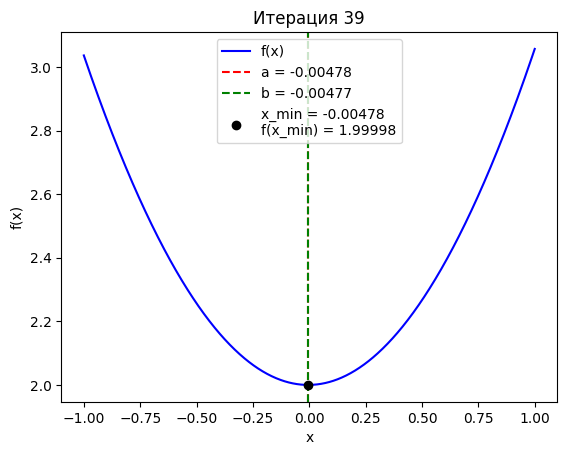

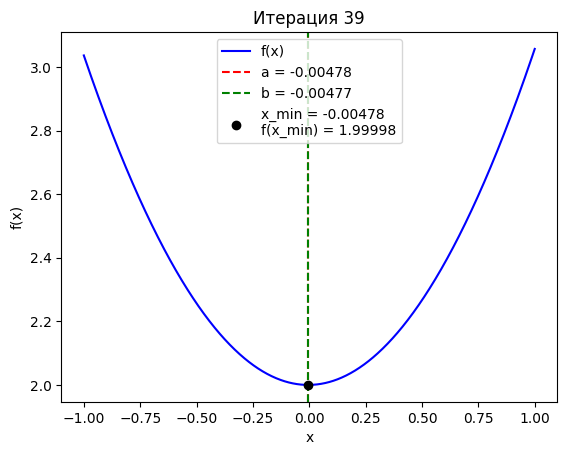

Итоговая погрешность дихотомии: 4.999999999999796e-06
x_min = -0.0047789800432036485
f(x) = 1.999976105112258


In [6]:
# запускаем с визуализацией
plt.ion()  # Включаем интерактивный режим для анимации
result_x = dichotomy(a=-3, b=3, eps=1e-5)
plt.ioff()  # выключаем интерактивный режим после завершения
# plt.show()  

print("x_min =", result_x)
print("f(x) =", func(result_x))

В какой-то момент на графике перестанут отображаться изменения. 
Это связано с тем, что мы обрезаем все значения в легенде до 6 знаков после запятой, т.е. происходят изменения в 7 и более порядках.


Стоит отметить, что минимайзер отличается от минимайзера у = х^2 из-за неравенства коэффициентов производной при экспонентах.
Не заметив этого сразу, проверил лишний раз на верность алгоритм, подставив нулевое значение функции. Получил ответ, бОльший найденного -> минимайзер действительно < 0

In [7]:
func(0)

np.float64(2.0)

In [8]:
@visualize_optimization
def golden_section(a, b, eps, update_plot=None):
    phi = 0.618
    while b - a >= eps:
        x1, x2 = a + (1 - phi) * (b - a), a + phi * (b - a)
        A, B = func(x1), func(x2)
        if A < B:
            b = x2
            #пересчет только А или В
        else:
            a = x1

        x_min = (a + b) / 2
        
        # обновляем график
        if update_plot:
            update_plot(a, b, eps, x_min, iteration)
    print(f'Итоговая погрешность золотого сечения: {(b-a)/2}')
    return x_min

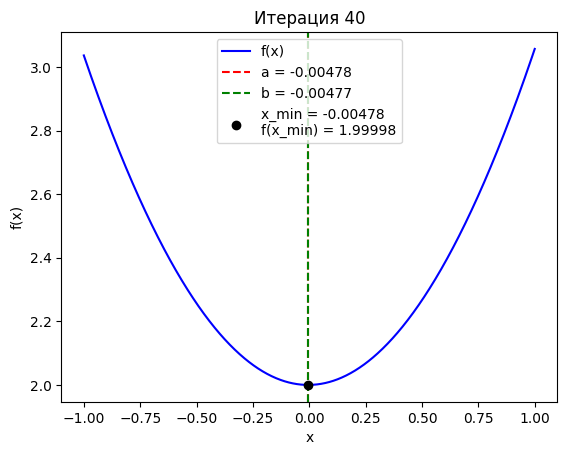

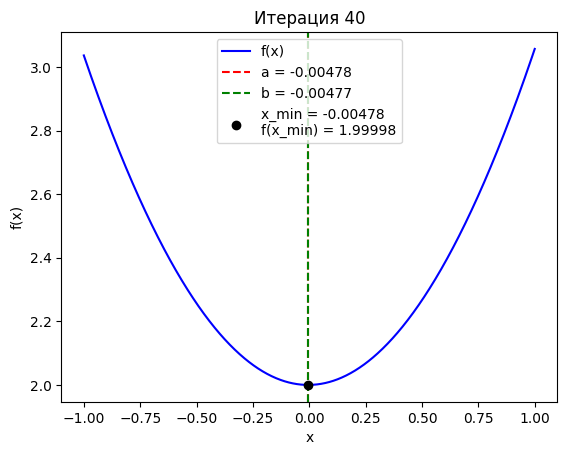

Итоговая погрешность дихотомии: 4.999999999999796e-06
x_min = -0.004778980058468172
f(x) = 1.999976105112258


In [9]:
# запускаем с визуализацией
plt.ion()  # Включаем интерактивный режим для анимации
result_x = dichotomy(a=-3, b=6, eps=1e-5)
plt.ioff()  # выключаем интерактивный режим после завершения
# plt.show()  

print("x_min =", result_x)
print("f(x) =", func(result_x))

In [10]:
@visualize_optimization
def fastest_down(a, b, eps):
    pass

In [13]:
from IPython.display import display, clear_output
import numpy as np
import matplotlib.pyplot as plt

# def func(x):
#     return (x - 2) ** 2

# def to_hex16(value):
#     print(value, np.float16(value), '\n',hex(np.float16(value)), hex(np.float16(value).view('H')))
#     return hex(np.float16(value).view('H'))
    
# def from_hex16(hex_value):
#     int_value = int(hex_value, 16)  # Переводим hex в int
#     return np.float16(np.frombuffer(int_value.to_bytes(2, 'little'), dtype=np.float16)[0])

# Декоратор для визуализации

def visualize_optimization(method):
    def wrapper(*args, **kwargs):
        def update_plot(a, b, eps, x_min, iteration):
            clear_output(wait=True) 
            plt.clf()
            x = np.linspace(-1, 1, 1000)
            y = func(x)
            plt.plot(x, y, label="f(x)", color="blue")
            plt.axvline(a, color="red", linestyle="--", label=f"a = {a:.5f}")
            plt.axvline(b, color="green", linestyle="--", label=f"b = {b:.5f}")
            plt.scatter([x_min], [func(x_min)], color="black", zorder=3, label=f"x_min = {x_min:.5f}\nf(x_min) = {func(x_min):.5f}")
            plt.legend()
            plt.title(f"Итерация {iteration}")
            plt.xlabel("x")
            plt.ylabel("f(x)")
            display(plt.gcf())
            plt.pause(0.2)
        return method(*args, update_plot=update_plot, **kwargs)
    return wrapper

@visualize_optimization
def dichotomy(a, b, eps, update_plot=None):
    iteration = 0
    a, b, eps = map(from_hex16, [a, b, eps])
    while b - a >= eps:
        iteration += 1
        delta = eps / 2
        a1, b1 = (a + b) / 2 - delta, (a + b) / 2 + delta
        left_value, right_value = func(a1), func(b1)
        if left_value < right_value:
            b = b1
        elif left_value > right_value:
            a = a1
        else:
            a, b = a1, b1
        x_min = (a + b) / 2
        if update_plot:
            update_plot(a, b, eps, x_min, iteration)
    print(f'Итоговая погрешность дихотомии: {(b-a)/2}')
    return to_hex16(x_min)

# Пример вызова
# hex_a, hex_b, hex_eps = to_hex16(-1), to_hex16(1), to_hex16(1e-6)
result = dichotomy(hex_a, hex_b, hex_eps)
# print("Минимум в 16-битной системе:", result, "(в 10-СС:)", from_hex16(result))


TypeError: 'numpy.float16' object cannot be interpreted as an integer